Models correlations — Figure 5

This notebook does:

1. Load a DNS vorticity field `w(t,x,y)` from a NetCDF file (variable name: `w`).
2. Compute tau of different models and compute the local correlations to tau, the flux correlations to tau and the ratio of the total fluxes to tau
3. Plot and save the data

This is done for DSMAG, DM, SIM, NGM4 and NGMR

In [1]:
# ----------------------------
# Imports & configuration
# ----------------------------
from __future__ import annotations

from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp

import jax_cfd.base as cfd
import jax_cfd.base.grids as grids
import jax_cfd.spectral as spectral

jax.config.update("jax_enable_x64", True)

In [2]:
# ----------------------------
# User knobs
# ----------------------------
# Note: You want to create a dataset at higher resolution and lower viscosity. 
# This is an example for 2048^2 data at nu = 1e-6, remember at higher Re (lower nu) you may want to also add the term \nu\frac{\sigma^6}{2} \nabla_k\nabla_l \nabla^2 \bar u_i \nabla_k \nabla_l \nabla^2 \bar u_j
INP = Path("/storage/home/hcoda1/4/mugliotti3/scratch/temporary/DNS.nc")

# Output: Where to save
OUT_DIR = Path("/storage/home/hcoda1/4/mugliotti3/scratch/temporary/")
OUT_DIR.mkdir(parents=True, exist_ok=True)
out_path = OUT_DIR / "LCR_metrics_vs_delta.txt"

# ----------------------------
# Some imports that are needed
# ----------------------------
ds = xr.open_dataset(INP)
if "w" not in ds:
    raise KeyError(f"Expected variable 'w' in {INP}, found: {list(ds.data_vars)}")
    
nu = float(ds.attrs["nu"])  
w0 = jnp.asarray(ds["w"].values)
if w0.ndim != 3:
    raise ValueError(f"Expected 2D vorticity field, got shape {w0.shape}")
Nt, Nx, Ny = w0.shape
w_hat_traj = jnp.fft.rfft2(w0, axes=(1,2))
print(f"Loaded w0 with shape (Nt, Nx, Ny) = {w0.shape}")
dt = float(ds.attrs["save_every"])  

Lengthscale = (2*jnp.pi/28)                 #Set you lengthscale here of you file
Delta_min = 0.01*Lengthscale                #Set minimum Delta you want
Delta_max = 1* Lengthscale                  #Set maximum Delta you want
Delta_amount = 20                           #How many Deltas in total to compute over

Loaded w0 with shape (Nt, Nx, Ny) = (10, 2048, 2048)


In [3]:
# ----------------------------
# Some functions we might need
# ----------------------------

from jax import vmap
def fourier_filter(field, Delta):

    if field.ndim not in (2, 3, 4):
        raise ValueError("field must have 2D, 3D, or 4D shape")

    Nx, Ny = field.shape[:2]

    qx = jnp.fft.fftfreq(Nx) * Nx
    qy = jnp.fft.fftfreq(Ny) * Ny
    X, Y = jnp.meshgrid(qy, qx)
    R2 = X**2 + Y**2
    G = jnp.exp(-R2 * (Delta**2) / 24.0).astype(field.dtype)

    def filt2(x2d):
        F = jnp.fft.fft2(x2d, axes=(-2, -1))
        Y = F * G
        y = jnp.fft.ifft2(Y, axes=(-2, -1))
        return y.real.astype(field.dtype) if jnp.isrealobj(field) else y.astype(field.dtype)

    if field.ndim == 2:
        return filt2(field)

    elif field.ndim == 3:  # (Nx,Ny,C)
        return vmap(filt2, in_axes=2, out_axes=2)(field)

    else:  # (Nx,Ny,C,T)
        def filt3(x3d):  # x3d = (Nx,Ny,C)
            return vmap(filt2, in_axes=2, out_axes=2)(x3d)
        return vmap(filt3, in_axes=3, out_axes=3)(field)

def C_maxnorm_3D(A: np.ndarray, B: np.ndarray) -> np.number:
    AB = np.sum(A * B, axis=(-2, -1))
    AA = np.sum(A * A, axis=(-2, -1))
    BB = np.sum(B * B, axis=(-2, -1))
    num    = np.sum(AB)
    AA_sum = np.sum(AA)
    BB_sum = np.sum(BB)
    den = np.maximum(AA_sum, BB_sum)
    return num / den

def compute_flux(S: np.ndarray, T: np.ndarray) -> np.number:
    ST = -np.sum(S * T, axis=(-2, -1))     
    return ST

In [4]:
# ----------------------------
# Convert omega to U,V
# ----------------------------
Nt, Nx, Ny = w0.shape   # w0 = (time, x, y)

grid = grids.Grid((Nx, Ny), domain=((0.0, 2*jnp.pi), (0.0, 2*jnp.pi)))
w_to_v_dns = spectral.utils.vorticity_to_velocity(grid)

# FFT per snapshot
w_hat = jnp.fft.rfft2(jnp.asarray(w0, dtype=jnp.float64), axes=(1, 2))
# shape: (Nt, Nx, Ny//2+1)

# ---- vectorize the operator over time ----
u_hat, v_hat = jax.vmap(w_to_v_dns)(w_hat)
# shapes: (Nt, Nx, Ny//2+1)

U = jnp.fft.irfft2(u_hat, axes=(1, 2))
V = jnp.fft.irfft2(v_hat, axes=(1, 2))
# shapes: (Nt, Nx, Ny)

# ---- transpose to what your ratios code expects ----
U = jnp.transpose(U, (1, 2, 0))   # (Nx, Ny, Nt)
V = jnp.transpose(V, (1, 2, 0))

u = jnp.stack((U, V), axis=-1) 

In [5]:
# ----------------------------
# Some more functions
# ----------------------------
def ngm_from_u_jnp(u_bar: jnp.ndarray, Delta: float):
    """
    u_bar: (Nx, Ny, Nt, 2) filtered velocity
    returns: L(=NGM2), C(=NGM4), S (all shape (Nx,Ny,Nt,2,2))
    """
    Nx, Ny, Nt, _ = u_bar.shape
    dx = 2*jnp.pi / Nx
    dy = 2*jnp.pi / Ny

    # angular wavenumbers (integers on 2π box)
    kx = jnp.fft.fftfreq(Nx, d=dx) * 2*jnp.pi
    ky = jnp.fft.fftfreq(Ny, d=dy) * 2*jnp.pi
    KX, KY = jnp.meshgrid(kx, ky, indexing='ij')  # (Nx,Ny)
    IKX = (1j * KX)[..., None]                    # (Nx,Ny,1)
    IKY = (1j * KY)[..., None]

    # FFT on spatial axes only
    uhat = jnp.fft.fftn(u_bar[..., 0], axes=(0, 1))   # (Nx,Ny,Nt)
    vhat = jnp.fft.fftn(u_bar[..., 1], axes=(0, 1))

    # first derivatives
    du_dx = jnp.fft.ifftn(IKX * uhat, axes=(0, 1)).real
    du_dy = jnp.fft.ifftn(IKY * uhat, axes=(0, 1)).real
    dv_dx = jnp.fft.ifftn(IKX * vhat, axes=(0, 1)).real
    dv_dy = jnp.fft.ifftn(IKY * vhat, axes=(0, 1)).real

    # second derivatives (∂_{xx}u etc.; (i k)^2 = -k^2 gives correct sign)
    d2u_dx2  = jnp.fft.ifftn((IKX**2)     * uhat, axes=(0, 1)).real
    d2u_dy2  = jnp.fft.ifftn((IKY**2)     * uhat, axes=(0, 1)).real
    d2u_dxdy = jnp.fft.ifftn((IKX*IKY)    * uhat, axes=(0, 1)).real
    d2v_dx2  = jnp.fft.ifftn((IKX**2)     * vhat, axes=(0, 1)).real
    d2v_dy2  = jnp.fft.ifftn((IKY**2)     * vhat, axes=(0, 1)).real
    d2v_dxdy = jnp.fft.ifftn((IKX*IKY)    * vhat, axes=(0, 1)).real

    L_xx = du_dx**2 + du_dy**2
    L_yy = dv_dx**2 + dv_dy**2
    L_xy = du_dx*dv_dx + du_dy*dv_dy
    L = (Delta**2/12.0) * jnp.stack(
        [jnp.stack([L_xx, L_xy], axis=-1),
         jnp.stack([L_xy, L_yy], axis=-1)], axis=-2)

    C_xx = d2u_dx2**2 + d2u_dy2**2 + 2.0*(d2u_dxdy**2)
    C_yy = d2v_dx2**2 + d2v_dy2**2 + 2.0*(d2v_dxdy**2)
    C_xy = d2u_dx2*d2v_dx2 + d2u_dy2*d2v_dy2 + 2.0*(d2u_dxdy*d2v_dxdy)
    C = (Delta**4/288.0) * jnp.stack(
        [jnp.stack([C_xx, C_xy], axis=-1),
         jnp.stack([C_xy, C_yy], axis=-1)], axis=-2)

    # symmetric rate-of-strain from filtered velocity: S_ij = (∂_i u_j + ∂_j u_i)/2
    # build grad u (j index = velocity component)
    grad_u = jnp.stack(
        [jnp.stack([du_dx, du_dy], axis=-1),   # i = x row
         jnp.stack([dv_dx, dv_dy], axis=-1)],  # i = y row
        axis=-2)                                # (...,2,2) with indices (i,j)

    S = 0.5 * (grad_u + jnp.swapaxes(grad_u, -2, -1))

    return L, C, S

# ---------- jnp helpers ----------
def compute_flux_jnp(T: jnp.ndarray, S: jnp.ndarray) -> jnp.ndarray:
    # double contraction over the last two indices
    return jnp.sum(T * S, axis=(-2, -1))

def C_maxnorm_3D_jnp(A: jnp.ndarray, B: jnp.ndarray) -> jnp.ndarray:
    AB = jnp.sum(A * B, axis=(-2, -1))
    AA = jnp.sum(A * A, axis=(-2, -1))
    BB = jnp.sum(B * B, axis=(-2, -1))
    num = jnp.sum(AB)
    den = jnp.maximum(jnp.sum(AA), jnp.sum(BB))
    return num / den

def corr_scalar(a, b):
    num = jnp.sum(a * b)
    den = jnp.maximum(jnp.sum(a * a), jnp.sum(b * b))
    return num / den

def fmt3(x):
    x = float(jnp.asarray(x))
    return f"{x:.10g}"

In [6]:
from tqdm import tqdm
def f_L_plus_DSmag_tau_time(
    u: jnp.ndarray,     # (Nx,Ny,Nt)
    v: jnp.ndarray,     # (Nx,Ny,Nt)
    Delta: float,
    Sxx: jnp.ndarray,
    Sxy: jnp.ndarray,
    Syy: jnp.ndarray,
    alpha_test: float = float(np.sqrt(2.0)),
    enforce_nu_pos: bool = True,
    Cs2_clip_max: float | None = None,   # e.g. 0.2**2 if you want
) -> tuple[jnp.ndarray, jnp.ndarray]:
    assert u.ndim == 3 and v.ndim == 3, "u, v must be (Nx, Ny, Nt)"
    assert Sxx.shape == u.shape == v.shape == Sxy.shape == Syy.shape, "All fields must share (Nx, Ny, Nt) shape"

    Nx, Ny, Nt = u.shape
    DeltaTest = alpha_test * Delta

    # |S|
    sI1 = jnp.sqrt(2.0 * (Sxx**2 + Syy**2 + 2.0 * Sxy**2) + EPS)

    # test-filtered strain and |S|
    TSxx = jnp.asarray(fourier_filter(Sxx, float(DeltaTest)))
    TSxy = jnp.asarray(fourier_filter(Sxy, float(DeltaTest)))
    TSyy = jnp.asarray(fourier_filter(Syy, float(DeltaTest)))
    TsI1 = jnp.sqrt(2.0 * (TSxx**2 + TSyy**2 + 2.0 * TSxy**2) + EPS)

    # Leonard at test scale
    Fu_T = jnp.asarray(fourier_filter(u, float(DeltaTest)))
    Fv_T = jnp.asarray(fourier_filter(v, float(DeltaTest)))
    LT_xx = jnp.asarray(fourier_filter(u * u, float(DeltaTest))) - Fu_T * Fu_T
    LT_xy = jnp.asarray(fourier_filter(u * v, float(DeltaTest))) - Fu_T * Fv_T
    LT_yy = jnp.asarray(fourier_filter(v * v, float(DeltaTest))) - Fv_T * Fv_T

    # Leonard at grid scale Δ (for tau_LD)
    Fu_D = jnp.asarray(fourier_filter(u, float(Delta)))
    Fv_D = jnp.asarray(fourier_filter(v, float(Delta)))
    Ld_xx = jnp.asarray(fourier_filter(u * u, float(Delta))) - Fu_D * Fu_D
    Ld_xy = jnp.asarray(fourier_filter(u * v, float(Delta))) - Fu_D * Fv_D
    Ld_yy = jnp.asarray(fourier_filter(v * v, float(Delta))) - Fv_D * Fv_D

    # Dynamic tensor M_ij
    # M_ij = -2 Δ^2 ( α^2 |Ŝ| Ŝ_ij - \widehat{|S| S_ij} )
    Mxx = -2.0 * (Delta**2) * ((alpha_test**2) * TsI1 * TSxx - jnp.asarray(fourier_filter(sI1 * Sxx, float(DeltaTest))))
    Mxy = -2.0 * (Delta**2) * ((alpha_test**2) * TsI1 * TSxy - jnp.asarray(fourier_filter(sI1 * Sxy, float(DeltaTest))))
    Myy = -2.0 * (Delta**2) * ((alpha_test**2) * TsI1 * TSyy - jnp.asarray(fourier_filter(sI1 * Syy, float(DeltaTest))))

    num = LT_xx * Mxx + LT_yy * Myy + 2.0 * LT_xy * Mxy
    den = Mxx * Mxx + Myy * Myy + 2.0 * Mxy * Mxy + EPS
    Cs2 = num / den

    if enforce_nu_pos:
        Cs2 = jnp.maximum(Cs2, 0.0)
    if Cs2_clip_max is not None:
        Cs2 = jnp.minimum(Cs2, float(Cs2_clip_max))

    # Eddy viscosity (broadcast Cs2(t) -> (Nx,Ny,Nt))
    nu_t = (Delta**2) * Cs2 * sI1

    # Deviatoric stress
    Dxx = -2.0 * nu_t * Sxx
    Dxy = -2.0 * nu_t * Sxy
    Dyy = -2.0 * nu_t * Syy

    # Pack tensors (Nx,Ny,Nt,2,2) in JAX
    tau_D = jnp.zeros((Nx, Ny, Nt, 2, 2), dtype=u.dtype)
    tau_D = tau_D.at[..., 0, 0].set(Dxx)
    tau_D = tau_D.at[..., 0, 1].set(Dxy)
    tau_D = tau_D.at[..., 1, 0].set(Dxy)
    tau_D = tau_D.at[..., 1, 1].set(Dyy)

    tau_LD = jnp.zeros((Nx, Ny, Nt, 2, 2), dtype=u.dtype)
    tau_LD = tau_LD.at[..., 0, 0].set(Ld_xx + Dxx)
    tau_LD = tau_LD.at[..., 0, 1].set(Ld_xy + Dxy)
    tau_LD = tau_LD.at[..., 1, 0].set(Ld_xy + Dxy)
    tau_LD = tau_LD.at[..., 1, 1].set(Ld_yy + Dyy)

    return tau_D, tau_LD

# ============================================================
# MAIN LOOP: compute raw_lines
# ============================================================
raw_lines = []
Deltas = np.linspace(Delta_min, Delta_max, Delta_amount)
EPS= 1e-30
for Delta in tqdm(Deltas):
    Delta = float(Delta)

    # filtered velocity at Δ
    u_bar = jnp.asarray(fourier_filter(u, Delta))  # (Nx,Ny,Nt,2)

    # true SGS tau = overline(u_i u_j) - ubar_i ubar_j
    uu_xx = jnp.asarray(fourier_filter(u[..., 0] * u[..., 0], Delta))
    uu_xy = jnp.asarray(fourier_filter(u[..., 0] * u[..., 1], Delta))
    uu_yy = jnp.asarray(fourier_filter(u[..., 1] * u[..., 1], Delta))
    tau = jnp.stack(
        [jnp.stack([uu_xx - u_bar[..., 0]**2, uu_xy - u_bar[..., 0]*u_bar[..., 1]], axis=-1),
         jnp.stack([uu_xy - u_bar[..., 0]*u_bar[..., 1], uu_yy - u_bar[..., 1]**2], axis=-1)],
        axis=-2
    )  # (Nx,Ny,Nt,2,2)

    # NGM2/NGM4 and strain from u_bar
    L_NGM, C, S = ngm_from_u_jnp(u_bar, Delta)

    # Leonard "Sim" tensor at Δ from u_bar (as you had it)
    u_bar_bar = jnp.asarray(fourier_filter(u_bar, Delta))
    uu_xx2 = jnp.asarray(fourier_filter(u_bar[..., 0]*u_bar[..., 0], Delta))
    uu_xy2 = jnp.asarray(fourier_filter(u_bar[..., 0]*u_bar[..., 1], Delta))
    uu_yy2 = jnp.asarray(fourier_filter(u_bar[..., 1]*u_bar[..., 1], Delta))
    L = jnp.stack(
        [jnp.stack([uu_xx2 - u_bar_bar[..., 0]**2, uu_xy2 - u_bar_bar[..., 0]*u_bar_bar[..., 1]], axis=-1),
         jnp.stack([uu_xy2 - u_bar_bar[..., 0]*u_bar_bar[..., 1], uu_yy2 - u_bar_bar[..., 1]**2], axis=-1)],
        axis=-2
    )

    # R from fluctuations (your construction)
    u_dash = u - u_bar
    u_bar_dash = jnp.asarray(fourier_filter(u_dash, Delta))
    R_xx = jnp.asarray(fourier_filter(u_dash[..., 0]*u_dash[..., 0], Delta)) - u_bar_dash[..., 0]**2
    R_xy = jnp.asarray(fourier_filter(u_dash[..., 0]*u_dash[..., 1], Delta)) - u_bar_dash[..., 0]*u_bar_dash[..., 1]
    R_yy = jnp.asarray(fourier_filter(u_dash[..., 1]*u_dash[..., 1], Delta)) - u_bar_dash[..., 1]**2
    R = jnp.stack(
        [jnp.stack([R_xx, R_xy], axis=-1),
         jnp.stack([R_xy, R_yy], axis=-1)],
        axis=-2
    )

    # Dynamic Smag tensors (IMPORTANT: pass u_bar components + S from u_bar)
    tau_D, tau_LD = f_L_plus_DSmag_tau_time(
        u=u_bar[..., 0],
        v=u_bar[..., 1],
        Delta=Delta,
        Sxx=S[..., 0, 0],
        Sxy=S[..., 0, 1],
        Syy=S[..., 1, 1],
        enforce_nu_pos=False,     # FIXED (prevents DSMAG from going weird)
        Cs2_clip_max=None        # optionally set to 0.2**2 if you want
    )

    # Define the 5 tensors in your Fig2 slots
    T_Sim   = L
    T_NGM4  = L_NGM + C
    T_NGMR  = L_NGM + C + R
    T_DSMAG = tau_D
    T_DM    = tau_LD

    # Local tensor correlations vs true tau
    LocCorr_Sim   = C_maxnorm_3D_jnp(tau, T_Sim)
    LocCorr_NGM4  = C_maxnorm_3D_jnp(tau, T_NGM4)
    LocCorr_NGMR  = C_maxnorm_3D_jnp(tau, T_NGMR)
    LocCorr_DSMAG = C_maxnorm_3D_jnp(tau, T_DSMAG)
    LocCorr_DM    = C_maxnorm_3D_jnp(tau, T_DM)

    # Fluxes Π = -T:S
    tau_flux = compute_flux_jnp(tau, S)
    F_Sim    = compute_flux_jnp(T_Sim, S)
    F_NGM4   = compute_flux_jnp(T_NGM4, S)
    F_NGMR   = compute_flux_jnp(T_NGMR, S)
    F_DSMAG  = compute_flux_jnp(T_DSMAG, S)
    F_DM     = compute_flux_jnp(T_DM, S)

    # Flux correlations
    FluxCorr_Sim   = corr_scalar(tau_flux, F_Sim)
    FluxCorr_NGM4  = corr_scalar(tau_flux, F_NGM4)
    FluxCorr_NGMR  = corr_scalar(tau_flux, F_NGMR)
    FluxCorr_DSMAG = corr_scalar(tau_flux, F_DSMAG)
    FluxCorr_DM    = corr_scalar(tau_flux, F_DM)

    # Global flux ratios (sum Π_model / sum Π_tau)
    tau_flux_sum = jnp.sum(tau_flux)
    GlobFlux_Sim   = jnp.sum(F_Sim)/tau_flux_sum
    GlobFlux_NGM4  = jnp.sum(F_NGM4)/tau_flux_sum
    GlobFlux_NGMR  = jnp.sum(F_NGMR)/tau_flux_sum
    GlobFlux_DSMAG = jnp.sum(F_DSMAG)/tau_flux_sum
    GlobFlux_DM    = jnp.sum(F_DM)/tau_flux_sum

    eps_val = Delta / Lengthscale

    vals = [
        LocCorr_Sim, LocCorr_NGM4, LocCorr_NGMR, LocCorr_DSMAG, LocCorr_DM,
        FluxCorr_Sim, FluxCorr_NGM4, FluxCorr_NGMR, FluxCorr_DSMAG, FluxCorr_DM,
        GlobFlux_Sim, GlobFlux_NGM4, GlobFlux_NGMR, GlobFlux_DSMAG, GlobFlux_DM,
    ]

    line = fmt3(eps_val) + "\t" + "\t".join(fmt3(v) for v in vals)
    raw_lines.append(line)

100%|██████████| 20/20 [00:08<00:00,  2.41it/s]


Saved -> /storage/home/hcoda1/4/mugliotti3/scratch/temporary/LCR_metrics_vs_delta.txt (cols=16)


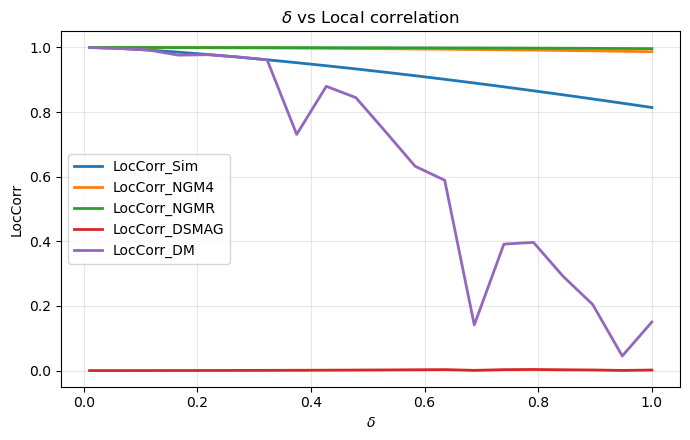

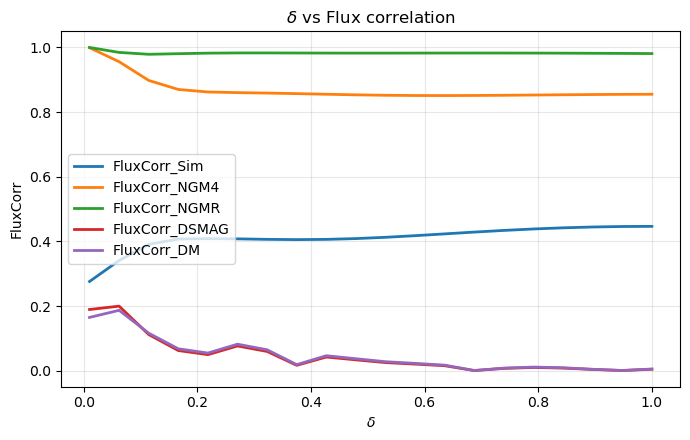

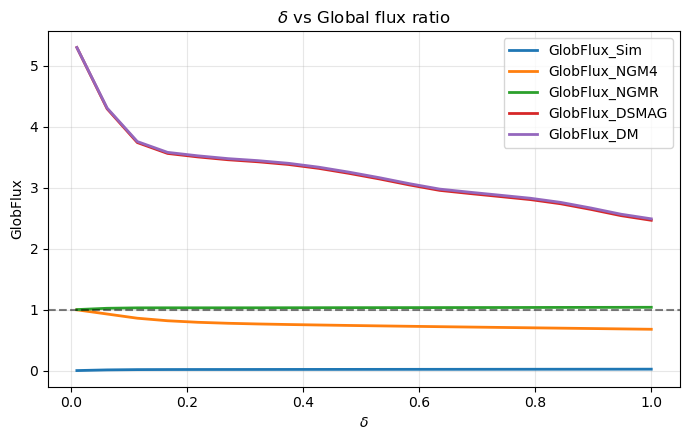

In [7]:
# ============================================================
# Save, load and plot
# ============================================================

header_names = [
    "delta",
    "LocCorr_Sim","LocCorr_NGM4","LocCorr_NGMR","LocCorr_DSMAG","LocCorr_DM",
    "FluxCorr_Sim","FluxCorr_NGM4","FluxCorr_NGMR","FluxCorr_DSMAG","FluxCorr_DM",
    "GlobFlux_Sim","GlobFlux_NGM4","GlobFlux_NGMR","GlobFlux_DSMAG","GlobFlux_DM",
]

def split_tab(ln: str):
    return [p for p in ln.strip().split("\t") if p != ""]

expected_cols = 1 + (len(header_names) - 1)  # data columns == header columns
ncols = len(split_tab(raw_lines[0]))
if ncols != expected_cols:
    raise ValueError(f"Column mismatch: raw_lines has {ncols} cols but header has {expected_cols}")

with open(out_path, "w") as f:
    f.write("\t".join(header_names) + "\n")   # TAB header (CRITICAL)
    for ln in raw_lines:
        f.write("\t".join(split_tab(ln)) + "\n")

print(f"Saved -> {out_path} (cols={ncols})")

data = np.genfromtxt(out_path, names=True, dtype=float, delimiter="\t")
if data.shape == ():
    data = np.array([data], dtype=data.dtype)

eps = data["delta"]

def plot_group(x, cols, title, ylabel, hline=None):
    idx = np.argsort(x)
    xs = x[idx]
    plt.figure(figsize=(7, 4.5))
    for c in cols:
        plt.plot(xs, data[c][idx], lw=2, label=c)
    if hline is not None:
        plt.axhline(hline, color="k", ls="--", alpha=0.5)
    plt.xlabel(r"$\delta$")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

# Original 3 panels
plot_group(eps,
           ["LocCorr_Sim","LocCorr_NGM4","LocCorr_NGMR","LocCorr_DSMAG","LocCorr_DM"],
           r"$\delta$ vs Local correlation", "LocCorr")
plot_group(eps,
           ["FluxCorr_Sim","FluxCorr_NGM4","FluxCorr_NGMR","FluxCorr_DSMAG","FluxCorr_DM"],
           r"$\delta$ vs Flux correlation", "FluxCorr")
plot_group(eps,
           ["GlobFlux_Sim","GlobFlux_NGM4","GlobFlux_NGMR","GlobFlux_DSMAG","GlobFlux_DM"],
           r"$\delta$ vs Global flux ratio", "GlobFlux", hline=1.0)